# CIFAR-10 — where Booleanization becomes the whole problem

MNIST is black ink on white paper: thresholding at 0.3 loses almost nothing. CIFAR-10 is
32×32 colour photographs, where "is this pixel on?" is not a meaningful question. Turning a
photograph into Boolean features *is* the modelling work, and it decides the accuracy ceiling
long before any Tsetlin hyper-parameter does.

This notebook is deliberately honest about the numbers. A Tsetlin machine of the size we can
train here lands far below a small CNN on CIFAR-10, and this notebook shows exactly where the
loss comes from. What you get in exchange is a model whose every rule is a coloured patch you
can look at, and one that says *where* it is failing: the last section shows the same machine
reaching ~89 % once the task is coarsened to vehicle vs animal, where colour and texture carry
the signal.

**What we do here**

1. Compare four booleanizations of the same images, and look at what each one preserves.
2. Train a convolutional Tsetlin machine on the best of them.
3. Evaluate per class, and find out which classes a TM can and cannot do.
4. Inspect the learned clauses as colour patches.
5. Scale the clause budget and see what it buys.
6. Re-run the pipeline on the binary vehicle/animal task.

In [1]:
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torchvision.datasets import CIFAR10

import torchtsetlin as tt

SEED = 0
tt.seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = "../../data"
CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

print("torchtsetlin", tt.__version__, "| torch", torch.__version__, "| device", device)
if device.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

# --- the configuration every cell below refers to ------------------------------------
BITS = 4                  # thermometer levels per colour channel -> 3*BITS Boolean planes
PATCH, STRIDE = 4, 2      # convolution window over those planes
CLAUSES_PER_CLASS = 1000
T_VALUE = 2 * CLAUSES_PER_CLASS   # vote margin scales with the clause budget (see section 6)
S_VALUE = 10.0                    # specificity
BATCH_SIZE = 100
EPOCHS = 15

# Shortened schedule for the ablations in section 6.
SWEEP_CLAUSES, SWEEP_EPOCHS, SWEEP_TRAIN = 200, 3, 20_000

torchtsetlin 0.1.1 | torch 2.10.0+cu128 | device cuda
gpu: NVIDIA GeForce RTX 3090


## 1. Four ways to booleanize a photograph

Every `torchtsetlin` encoder takes a float tensor `(N, 3, 32, 32)` scaled to `[0, 1]` and
returns Booleans, so we keep the raw images once and re-encode them per experiment. (For the
one-encoder case, `tt.data.load_torchvision_boolean(CIFAR10, root, train, encoder=...)` does the
load-and-encode in a single call.) The four candidates:

| encoder | output planes | idea |
|---|---|---|
| `Binarizer(0.5)` on grayscale | 1 | one bit per pixel — the MNIST recipe |
| `AdaptiveThresholdEncoder` | 3 | pixel vs. its *local* mean, per channel: keeps edges, discards illumination |
| `ColorThermometerEncoder(n_bits=4)` | 12 | per channel, 4 ordered intensity levels |
| `ColorThermometerEncoder(n_bits=8)` | 24 | same, at twice the resolution |

The thermometer is the one that keeps *ordering*: `[v>=0.2, v>=0.4, v>=0.6, v>=0.8]` lets a
clause say "this pixel's red channel is at least medium" with one literal, and "medium but not
bright" with two.

In [2]:
def load_raw(train):
    """CIFAR-10 as float (N, 3, 32, 32) in [0, 1], kept in host memory."""
    ds = CIFAR10(root=DATA_ROOT, train=train, download=True)
    x = torch.as_tensor(ds.data).permute(0, 3, 1, 2).float().div_(255.0)
    return x, torch.as_tensor(ds.targets).long()


def encode(encoder, x, chunk=5000):
    """Apply a Boolean encoder in chunks and keep the result on the device."""
    return torch.cat([encoder(x[i:i + chunk]).to(device) for i in range(0, len(x), chunk)])


raw_train, labels_train = load_raw(train=True)
raw_test, labels_test = load_raw(train=False)
y_train = labels_train.to(device)
y_test = labels_test.to(device)
print(f"raw train {tuple(raw_train.shape)} | raw test {tuple(raw_test.shape)} "
      f"({raw_train.numel() * 4 / 2**30:.1f} GB float32 in host memory)")

raw train (50000, 3, 32, 32) | raw test (10000, 3, 32, 32) (0.6 GB float32 in host memory)


In [3]:
GRAY_WEIGHTS = torch.tensor([0.299, 0.587, 0.114], device=device).view(1, 3, 1, 1)
_adaptive = tt.data.AdaptiveThresholdEncoder(5, 0.02).to(device)


def grayscale_threshold(x):
    return (x.to(device) * GRAY_WEIGHTS).sum(1, keepdim=True) > 0.5


encodings = {
    "grayscale > 0.5": grayscale_threshold,
    "adaptive threshold": _adaptive,
    "colour thermometer (4 bits)": tt.data.ColorThermometerEncoder(4, (0.0, 1.0)).to(device),
    "colour thermometer (8 bits)": tt.data.ColorThermometerEncoder(8, (0.0, 1.0)).to(device),
}

probe = raw_train[:2000]
summary = []
for name, enc in encodings.items():
    xb = encode(enc, probe)
    summary.append({"encoding": name, "shape": str(tuple(xb.shape[1:])),
                    "Boolean features/image": int(np.prod(xb.shape[1:])),
                    "fraction ON": round(float(xb.float().mean()), 3)})
pd.DataFrame(summary)

,encoding,shape,Boolean features/image,fraction ON
0,grayscale > 0.5,"(1, 32, 32)",1024,0.455
1,adaptive threshold,"(3, 32, 32)",3072,0.725
2,colour thermometer (4 bits),"(12, 32, 32)",12288,0.468
3,colour thermometer (8 bits),"(24, 32, 32)",24576,0.470


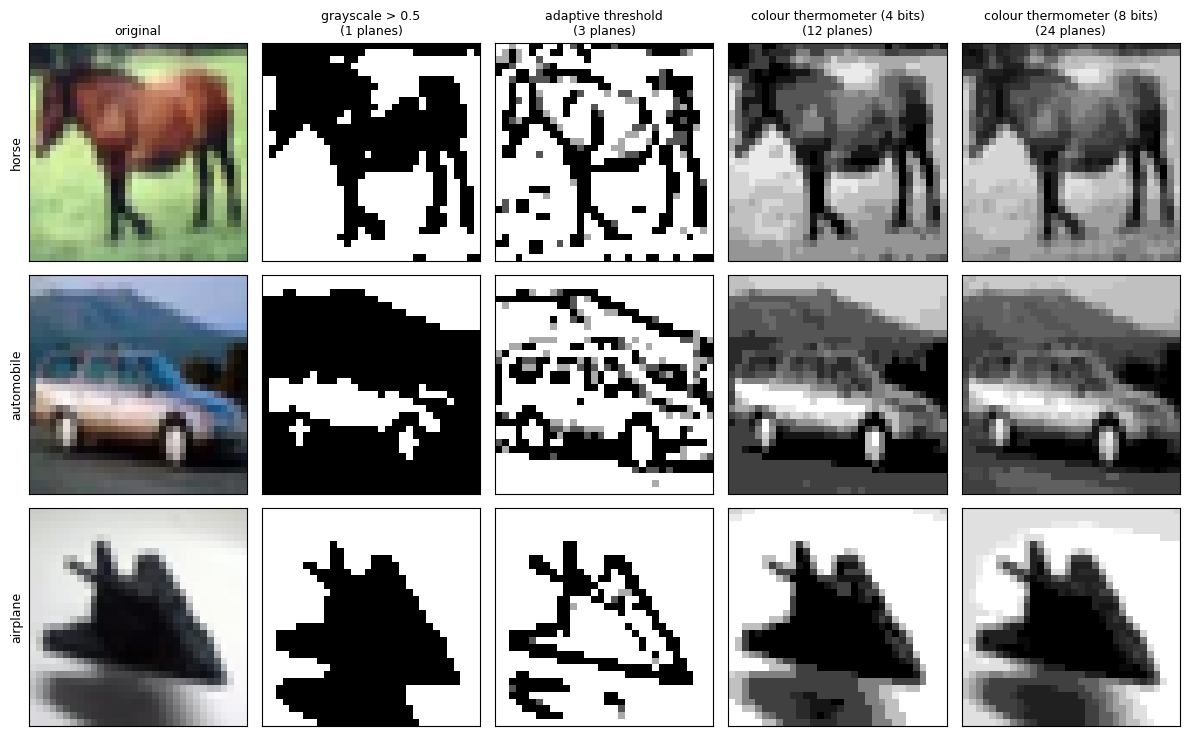

In [4]:
# What survives each encoding, for one image per row.
show = [7, 4, 29]
sample = raw_train[show]
fig, axes = plt.subplots(len(show), 5, figsize=(12, 2.5 * len(show)))
for r in range(len(show)):
    axes[r, 0].imshow(sample[r].permute(1, 2, 0).numpy())
    axes[r, 0].set_ylabel(CLASSES[int(labels_train[show[r]])], fontsize=9)
    if r == 0:
        axes[r, 0].set_title("original", fontsize=9)
for c, (name, enc) in enumerate(encodings.items(), start=1):
    planes = encode(enc, sample).float().cpu()
    for r in range(len(show)):
        # Mean over planes: how much evidence survives at each pixel.
        axes[r, c].imshow(planes[r].mean(0), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    axes[0, c].set_title(f"{name}\n({planes.shape[1]} planes)", fontsize=9)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Grayscale thresholding destroys the image: a dark cat on a dark sofa becomes a solid block.
Adaptive thresholding keeps the edges but throws away all colour — and colour is most of what
separates a deer from a truck at 32×32. The thermometer encodings keep both, at the cost of
12 or 24 Boolean planes per image instead of 1.

That cost is real. A 4×4 patch over 12 planes is `4*4*12 = 192` Boolean features, so 384
literals per clause; at 8 bits it is 768. Every clause evaluation touches all of them.

## 2. Does the encoding actually matter? Measure it.

Pictures are suggestive; accuracy is not. Same model, same budget, same schedule — only the
encoding changes. Five epochs of a small convolutional machine is enough to rank them.

In [5]:
enc_rows = []
for name, enc in encodings.items():
    tt.seed_everything(SEED)
    xtr, xte = encode(enc, raw_train), encode(enc, raw_test)
    planes = xtr.shape[1]
    m = tt.ConvTsetlinMachine(10, 200, T=500.0, s=10.0, patch_size=PATCH, stride=STRIDE,
                              position_encoding=True, input_shape=(planes, 32, 32),
                              weighted=True).to(device)
    tr = tt.Trainer(m, batch_size=BATCH_SIZE, verbose=False)
    t0 = time.time()
    tr.fit((xtr, y_train), epochs=5)
    enc_rows.append({"encoding": name, "planes": planes,
                     "fraction ON": round(float(xtr.float().mean()), 3),
                     "accuracy (5 epochs)": round(tr.evaluate((xte, y_test))["accuracy"], 4),
                     "seconds": round(time.time() - t0)})
    del m, xtr, xte
    if device.type == "cuda":
        torch.cuda.empty_cache()
pd.DataFrame(enc_rows)

,encoding,planes,fraction ON,accuracy (5 epochs),seconds
0,grayscale > 0.5,1,0.453,0.3391,12
1,adaptive threshold,3,0.727,0.4242,12
2,colour thermometer (4 bits),12,0.467,0.4574,18
3,colour thermometer (8 bits),24,0.470,0.4561,26


There is the answer, and it is not subtle: **the encoding moves accuracy by about 12 points**,
more than any single Tsetlin hyper-parameter in section 6. Grayscale thresholding is
catastrophic — it throws away the colour that separates a deer from a truck. Adaptive
thresholding recovers most of the gap by keeping three channels of edge information. The
thermometer wins because it keeps colour *and* its ordering.

Note where the gain stops: 8 bits costs roughly twice the compute of 4 and buys nothing. Four
levels per channel is enough resolution for 32×32 photographs, so that is what we use below.

## 3. A convolutional Tsetlin machine on CIFAR-10

Same model class as the MNIST notebook, with three changes forced by the data:

* **Small patches** (4×4). Photographs have no canonical stroke size, and a large patch over 12
  planes is an enormous literal space — an 8×8 window over 12 planes is 768 Boolean features per
  patch, and section 6 shows it does worse, not better.
* **Stride 2.** At stride 1 a 3×3 window gives 900 patches per image; stride 2 with a 4×4 window
  gives 225. Section 6 measures what that costs: about 2-3 accuracy points for ~2.5x the speed.
* **A large `T`, scaled to the clause budget.** `T` is how many votes must agree before feedback
  stops. With 1000 clauses per class and `T=100`, a handful of clauses saturate the vote and the
  rest never learn. `T = 2 x n_clauses` works well across the budgets tried here.
* **A big clause budget.** This is the knob that actually moves CIFAR-10 accuracy: going from
  200 to 1000 clauses per class is worth more than any other single change below.

In [6]:
encoder = tt.data.ColorThermometerEncoder(BITS, (0.0, 1.0)).to(device)

x_train = encode(encoder, raw_train)
x_test = encode(encoder, raw_test)
print(f"train {tuple(x_train.shape)} | test {tuple(x_test.shape)} | {x_train.dtype}")
print(f"device memory: {x_train.numel() / 2**20:.0f} MB")

train (50000, 12, 32, 32) | test (10000, 12, 32, 32) | torch.bool
device memory: 586 MB


In [7]:
tt.seed_everything(SEED)

model = tt.ConvTsetlinMachine(
    n_classes=10,
    n_clauses=CLAUSES_PER_CLASS,
    T=T_VALUE,
    s=S_VALUE,
    patch_size=PATCH,
    stride=STRIDE,
    position_encoding=True,
    input_shape=(3 * BITS, 32, 32),
    weighted=True,
).to(device)

print(model)
print(f"\npatches per image: {((32 - PATCH) // STRIDE + 1) ** 2}")
print(f"Boolean features per patch: {model.n_features}")
print(f"automata: {model.ta_state.numel():,} "
      f"({model.ta_state.numel() * 4 / 2**20:.0f} MB)")

ConvTsetlinMachine(patch_size=(4, 4), stride=(2, 2), position_encoding=True, input_shape=(12, 32, 32), n_classes=10, n_clauses_per_class=1000, T=2000.0, weighted=True, n_features=220, n_clauses_total=10000, n_states=128, s=10.0)

patches per image: 225
Boolean features per patch: 220
automata: 4,400,000 (17 MB)


In [8]:
trainer = tt.Trainer(model, batch_size=BATCH_SIZE, verbose=True)

t0 = time.time()
history = trainer.fit((x_train, y_train), epochs=EPOCHS, val_data=(x_test, y_test))
elapsed = time.time() - t0

metrics = trainer.evaluate((x_test, y_test))
print(f"\n{elapsed:.0f}s total | {EPOCHS * len(x_train) / elapsed:,.0f} examples/s")
print("conv TM:", metrics)

epoch   1 |   16.6s | batch_accuracy=0.3679 val_accuracy=0.4388


epoch   2 |   16.7s | batch_accuracy=0.4720 val_accuracy=0.4819


epoch   3 |   16.7s | batch_accuracy=0.5114 val_accuracy=0.5027


epoch   4 |   16.8s | batch_accuracy=0.5372 val_accuracy=0.5198


epoch   5 |   16.8s | batch_accuracy=0.5532 val_accuracy=0.5272


...

epoch  12 |   16.8s | batch_accuracy=0.6171 val_accuracy=0.5609


epoch  13 |   16.8s | batch_accuracy=0.6248 val_accuracy=0.5551


epoch  14 |   16.8s | batch_accuracy=0.6296 val_accuracy=0.5605


epoch  15 |   16.8s | batch_accuracy=0.6349 val_accuracy=0.5556



251s total | 2,988 examples/s
conv TM: {'accuracy': 0.5555999875068665}


## 4. Evaluation — which classes work?

In [9]:
model.eval()
votes = model(x_test)
pred = votes.argmax(1)
cm = tt.metrics.confusion_matrix(votes, y_test, n_classes=10)

print(tt.metrics.classification_report(votes, y_test, CLASSES))

            precision  recall  f1-score  support
airplane    0.555      0.633   0.591     1000
automobile  0.666      0.697   0.681     1000
bird        0.390      0.442   0.415     1000
cat         0.401      0.420   0.410     1000
deer        0.482      0.433   0.456     1000
dog         0.505      0.473   0.488     1000
frog        0.650      0.632   0.641     1000
horse       0.641      0.563   0.600     1000
ship        0.657      0.643   0.650     1000
truck       0.640      0.620   0.630     1000

accuracy    0.556
macro avg   0.559      0.556   0.556     10000


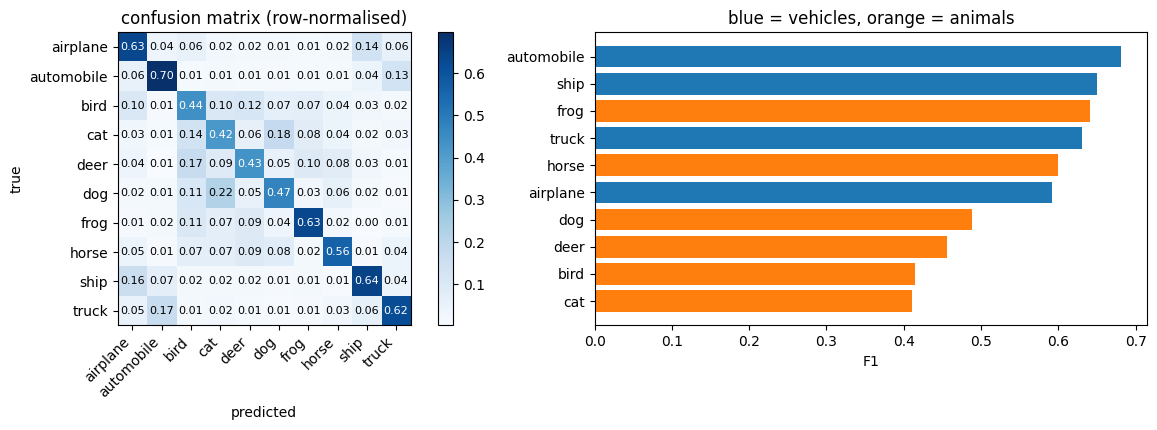

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
tt.viz.plot_confusion_matrix(cm, CLASSES, normalize=True, ax=axes[0])
axes[0].set_title("confusion matrix (row-normalised)")

per_class = tt.metrics.precision_recall_f1(cm)["f1"]
order = per_class.argsort(descending=True)
axes[1].barh(range(10)[::-1], per_class[order].cpu().numpy(),
             color=["tab:blue" if CLASSES[i] in ("airplane", "automobile", "ship", "truck")
                    else "tab:orange" for i in order.tolist()])
axes[1].set_yticks(range(10)[::-1], [CLASSES[i] for i in order.tolist()])
axes[1].set_xlabel("F1")
axes[1].set_title("blue = vehicles, orange = animals")
plt.tight_layout()
plt.show()

All four vehicle classes sit in the top half, joined by *frog* (uniform green, distinctive
texture) and *horse*. The bottom four are bird, cat, deer and dog — classes that share a colour
palette (brown and green), a texture (fur or feathers against foliage) and an ambiguous
silhouette at 32×32.

That is the qualitative story. The model will also tell us *why*, quantitatively.

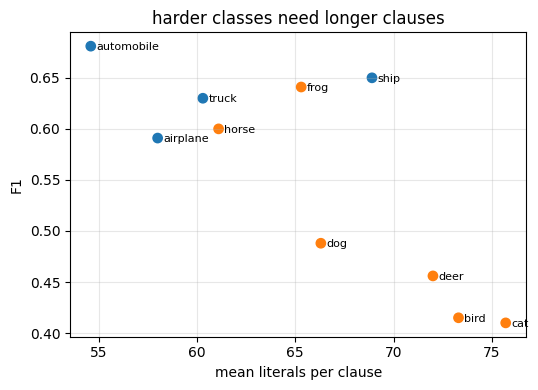

,class,F1,clause precision,literals/clause
0,automobile,0.681,0.175,54.6
1,ship,0.650,0.193,68.9
2,frog,0.641,0.169,65.3
3,truck,0.630,0.165,60.3
4,horse,0.600,0.144,61.1
5,airplane,0.591,0.156,58.0
6,dog,0.488,0.161,66.3
7,deer,0.456,0.147,72.0
8,bird,0.415,0.132,73.3
9,cat,0.410,0.142,75.7


In [11]:
# For each class: how reliable are its clauses, and how long do they have to be?
prec = tt.interpret.clause_precision(model, x_test, y_test)

rows = []
for k in range(10):
    sel = ((model.clause_class == k) & (model.clause_polarity > 0)
           & (model.include_count > 0))
    idx = torch.nonzero(sel).flatten()
    rows.append({"class": CLASSES[k],
                 "F1": round(float(per_class[k]), 3),
                 "clause precision": round(float(prec["precision"][idx].mean()), 3),
                 "literals/clause": round(float(model.include_count[idx].float().mean()), 1)})
table = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(5.5, 4))
is_vehicle = [c in ("airplane", "automobile", "ship", "truck") for c in table["class"]]
ax.scatter(table["literals/clause"], table["F1"],
           c=["tab:blue" if v else "tab:orange" for v in is_vehicle], s=45)
for _, r in table.iterrows():
    ax.annotate(r["class"], (r["literals/clause"], r["F1"]), fontsize=8,
                xytext=(4, -3), textcoords="offset points")
ax.set_xlabel("mean literals per clause")
ax.set_ylabel("F1")
ax.set_title("harder classes need longer clauses")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

table

The scatter is the point of this whole notebook. The classes the machine handles well are the
ones it can describe **briefly** — automobile needs ~55 literals per clause, airplane ~58. The
classes it fails on need the longest, most specific clauses: cat ~76, bird ~73, deer ~72. A long
clause is a memorised special case; it matches few images and generalises poorly, which is
exactly what the low clause precision for those classes shows.

So the model is not merely worse on cats — it is telling you, in a number you can read off the
automata, that it found no compact logical description of a cat at this resolution. A CNN's
accuracy figure carries no comparable diagnosis.

  coverage   accuracy
     100%      0.5556
      75%      0.6148
      50%      0.6924
      25%      0.7813
      10%      0.8700


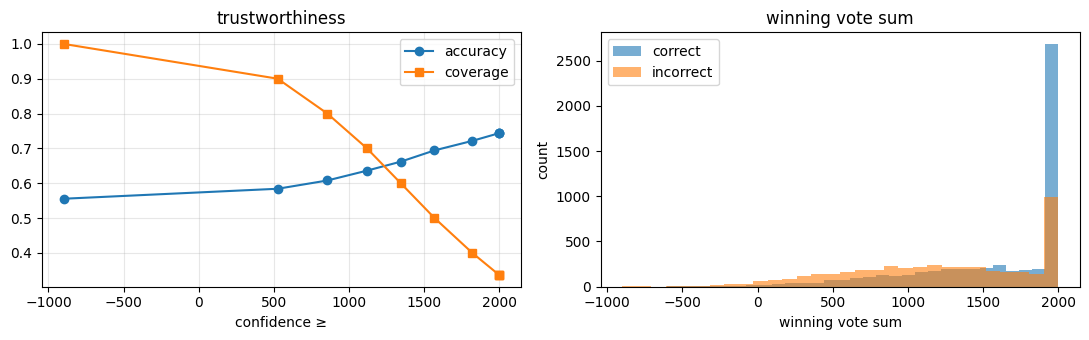

In [12]:
# Confidence-based abstention: the vote margin is informative even when accuracy is modest.
margin = tt.metrics.vote_margin(votes)
correct = (pred == y_test)
print(f"{'coverage':>10s}  {'accuracy':>9s}")
for q in (0.0, 0.25, 0.5, 0.75, 0.9):
    keep = margin >= torch.quantile(margin.float(), q)
    print(f"{keep.float().mean():>9.0%}   {correct[keep].float().mean():>9.4f}")

curve = tt.metrics.trustworthiness_curve(votes, y_test, n_levels=10)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
tt.viz.plot_trustworthiness(curve, ax=axes[0]); axes[0].set_title("trustworthiness")
tt.viz.plot_votes(votes, y_test, ax=axes[1]); axes[1].set_title("winning vote sum")
plt.tight_layout()
plt.show()

Even at ~56 % accuracy the model knows when it is guessing. Keeping only the most confident
quarter of the test set lifts accuracy to ~78 %, and the most confident tenth reaches ~87 %. For
a screening application — triage the confident cases, send the rest to a human — that is the
number that matters, and a Tsetlin machine gives it to you directly from the vote margin.

## 5. The clauses are coloured patches

Each clause is a `PATCH × PATCH` window over `3 × BITS` planes. Plane `c * BITS + b` is "channel `c` is at
least level `b`", so we can reconstruct the approximate colour a clause is looking for: count
how many thermometer levels of each channel the clause requires, and render that as an RGB
patch. Grey means "don't care".

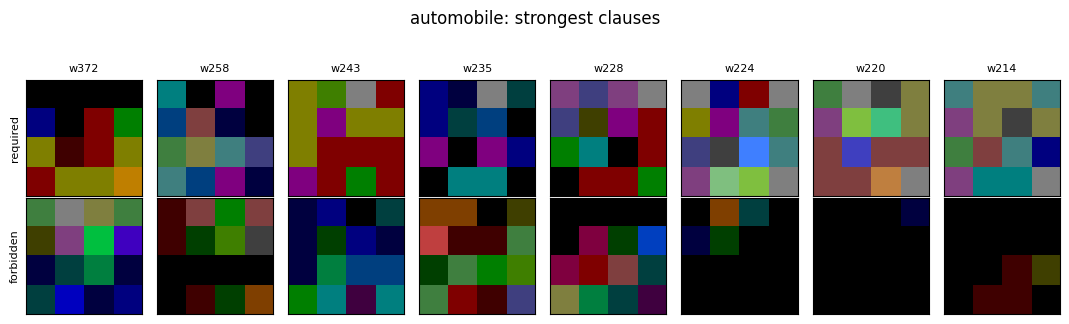

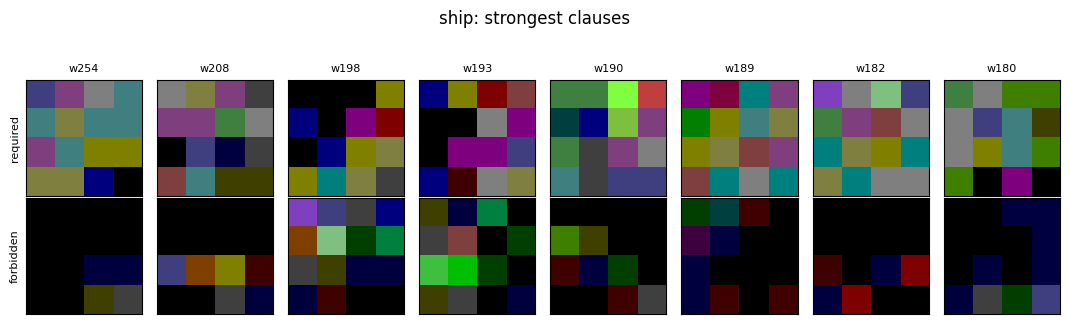

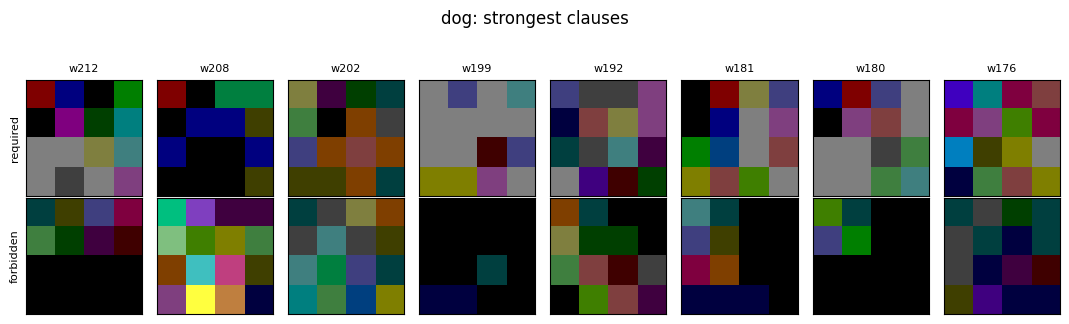

In [13]:
def clause_rgb(model, clause, bits=BITS):
    """Render a clause as (required_colour, mask) RGB patches."""
    patch = model.clause_patch(clause).float().cpu()          # (3*bits, kh, kw): +1/-1/0
    kh, kw = patch.shape[1:]
    per_channel = patch.reshape(3, bits, kh, kw)
    required = (per_channel > 0).float().sum(1) / bits         # lower bound on intensity
    forbidden = (per_channel < 0).float().sum(1) / bits        # upper bound
    touched = ((per_channel != 0).any(1)).float()              # which channels are constrained
    colour = required + 0.5 * (1 - touched)                    # grey where unconstrained
    return colour.permute(1, 2, 0).clamp(0, 1), forbidden.permute(1, 2, 0).clamp(0, 1)


def show_clauses(model, class_index, n=8):
    mask = ((model.clause_class == class_index) & (model.clause_polarity > 0)
            & (model.include_count > 0))
    idx = torch.nonzero(mask).flatten()
    top = idx[model.weights[idx].argsort(descending=True)][:n].tolist()
    fig, axes = plt.subplots(2, n, figsize=(1.35 * n, 3.1))
    for c, j in enumerate(top):
        colour, forbidden = clause_rgb(model, j)
        axes[0, c].imshow(colour.numpy(), interpolation="nearest")
        axes[0, c].set_title(f"w{int(model.weights[j])}", fontsize=8)
        axes[1, c].imshow(forbidden.numpy(), interpolation="nearest")
        for r in (0, 1):
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[0, 0].set_ylabel("required", fontsize=8)
    axes[1, 0].set_ylabel("forbidden", fontsize=8)
    fig.suptitle(f"{CLASSES[class_index]}: strongest clauses", y=1.04)
    plt.tight_layout()
    plt.show()


for k in (1, 8, 5):          # automobile, ship, dog
    show_clauses(model, k)

Read these against the scatter plot above. The vehicle clauses tend to pair a bright,
low-saturation patch (metal, sky) with a dark one, often pinned to a band of the image by the
position literals. The dog clauses are muddier — browns and greens with more constrained pixels
per clause, which is the visual form of the "more literals, lower precision" pattern the table
measured.

## 6. What do the Tsetlin hyper-parameters buy?

Now the model's own knobs, one at a time, on a shortened schedule. Compare the spread here with
the 15-point spread in section 2 — on this dataset the encoding is the dominant decision, and
the Tsetlin hyper-parameters are fine-tuning on top of it.

In [14]:
def quick_run(bits=BITS, patch=PATCH, stride=STRIDE, clauses=SWEEP_CLAUSES,
              T=2.0 * SWEEP_CLAUSES, s=S_VALUE, epochs=SWEEP_EPOCHS, n_train=SWEEP_TRAIN):
    tt.seed_everything(SEED)
    if bits == BITS:
        xtr, xte = x_train[:n_train], x_test            # reuse the encoding we already have
    else:
        enc = tt.data.ColorThermometerEncoder(bits, (0.0, 1.0)).to(device)
        xtr, xte = encode(enc, raw_train[:n_train]), encode(enc, raw_test)
    ytr = y_train[:n_train]
    m = tt.ConvTsetlinMachine(10, clauses, T=T, s=s, patch_size=patch, stride=stride,
                              position_encoding=True, input_shape=(3 * bits, 32, 32),
                              weighted=True).to(device)
    tr = tt.Trainer(m, batch_size=BATCH_SIZE, verbose=False)
    t0 = time.time()
    tr.fit((xtr[:n_train], ytr), epochs=epochs)
    acc = round(tr.evaluate((xte, y_test))["accuracy"], 4)
    del m
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return acc, round(time.time() - t0, 1)


rows = []
for clauses in (100, 200, 500):
    acc, secs = quick_run(clauses=clauses, T=2.0 * clauses)     # T scaled with the budget
    rows.append({"knob": "clauses/class (T=2x)", "value": clauses, "accuracy": acc, "seconds": secs})
for T in (100.0, 400.0, 1000.0, 2500.0):
    acc, secs = quick_run(T=T)
    rows.append({"knob": f"T (at {SWEEP_CLAUSES} clauses)", "value": T, "accuracy": acc, "seconds": secs})
for s in (5.0, 10.0, 25.0):
    acc, secs = quick_run(s=s)
    rows.append({"knob": "s (specificity)", "value": s, "accuracy": acc, "seconds": secs})
for patch, stride in ((3, 1), (4, 2), (8, 4)):
    acc, secs = quick_run(patch=patch, stride=stride)
    rows.append({"knob": "patch/stride", "value": f"{patch}/{stride}", "accuracy": acc, "seconds": secs})
pd.DataFrame(rows)

,knob,value,accuracy,seconds
0,clauses/class (T=2x),100,0.3588,3.2
1,clauses/class (T=2x),200,0.3962,4.7
2,clauses/class (T=2x),500,0.4302,9.8
3,T (at 200 clauses),100.0,0.3742,4.7
4,T (at 200 clauses),400.0,0.3962,4.7
5,T (at 200 clauses),1000.0,0.3867,4.7
6,T (at 200 clauses),2500.0,0.3597,4.7
7,s (specificity),5.0,0.4112,4.7
8,s (specificity),10.0,0.3962,4.7
9,s (specificity),25.0,0.3505,4.7


Three things the table says:

* **Clause budget is the real dial**, and `T` has to grow with it. That is why the model above
  uses 1000 clauses per class rather than the 200 used for these ablations.
* **`T` has a broad optimum around twice the clause count, and degrades in both directions.**
  Too small and a few clauses saturate the class vote while the rest sit idle; too large and the
  feedback probability never falls off, so the automata keep churning instead of settling.
* **Patch geometry is a compute trade, not a free win.** A 3×3 window at stride 1 scores higher
  and costs several times more; an 8×8 window costs more *and* scores lower, because the literal
  space per clause explodes while the number of patches collapses.

One caveat on reading any of this: these ablations run at a fifth of the clause budget on 40 %
of the data for 3 epochs, and rankings *can* flip at full scale. `s=5` wins this table, but at
1000 clauses per class for 15 epochs `s=10` is clearly better. Short-schedule ablations are for
narrowing the search, not for settling it.

## 7. The same machine on a task it is suited for

CIFAR-10's ten-way split asks for fine-grained texture discrimination. Collapse it to the
coarse **vehicle vs animal** question — the distinction colour and shape actually carry at
32×32 — and the same architecture, with the same clause budget, behaves very differently.

In [15]:
VEHICLES = torch.tensor([0, 1, 8, 9], device=device)      # airplane, automobile, ship, truck

y_train_bin = torch.isin(y_train, VEHICLES).long()
y_test_bin = torch.isin(y_test, VEHICLES).long()
print(f"vehicles: {float(y_train_bin.float().mean()):.0%} of the training set")

tt.seed_everything(SEED)
binary = tt.ConvTsetlinMachine(
    n_classes=2, n_clauses=CLAUSES_PER_CLASS, T=T_VALUE, s=S_VALUE,
    patch_size=PATCH, stride=STRIDE, position_encoding=True,
    input_shape=(3 * BITS, 32, 32), weighted=True,
).to(device)

bin_trainer = tt.Trainer(binary, batch_size=BATCH_SIZE, verbose=True)
bin_trainer.fit((x_train, y_train_bin), epochs=10, val_data=(x_test, y_test_bin))

binary.eval()
votes_bin = binary(x_test)
print()
print(tt.metrics.classification_report(votes_bin, y_test_bin, ["animal", "vehicle"]))

vehicles: 40% of the training set


epoch   1 |    4.0s | batch_accuracy=0.8110 val_accuracy=0.8472


epoch   2 |    4.0s | batch_accuracy=0.8564 val_accuracy=0.8629


epoch   3 |    4.0s | batch_accuracy=0.8719 val_accuracy=0.8711


epoch   4 |    4.0s | batch_accuracy=0.8810 val_accuracy=0.8782


...

epoch   7 |    4.0s | batch_accuracy=0.8965 val_accuracy=0.8862


epoch   8 |    4.0s | batch_accuracy=0.9011 val_accuracy=0.8903


epoch   9 |    4.0s | batch_accuracy=0.9046 val_accuracy=0.8916


epoch  10 |    4.0s | batch_accuracy=0.9074 val_accuracy=0.8914



           precision  recall  f1-score  support
animal     0.916      0.902   0.909     6000
vehicle    0.856      0.875   0.866     4000

accuracy   0.891
macro avg  0.886      0.889   0.887     10000


In [16]:
# Which of the original ten classes does the binary model get wrong?
pred_bin = votes_bin.argmax(1)
per_class_acc = [(CLASSES[k], float((pred_bin[y_test == k] == y_test_bin[y_test == k]).float().mean()))
                 for k in range(10)]
for name, acc in sorted(per_class_acc, key=lambda t: -t[1]):
    print(f"  {name:<12s} {acc:.3f}")

  frog         0.954
  dog          0.933
  ship         0.907
  cat          0.905
  deer         0.905
  automobile   0.898
  horse        0.872
  truck        0.863
  bird         0.843
  airplane     0.834


Note which classes the binary model finds hardest: **airplane and bird**. Both are small objects
against a large expanse of sky, so at 4×4 patches over a colour thermometer they look almost
identical — the machine is confusing exactly the two classes that share a background. Frog and
dog, at the other end, are never mistaken for vehicles.

In [17]:
torch.save({"model": model.state_dict(), "encoder": encoder.state_dict()}, "cifar10_conv_tm.pt")
print("saved cifar10_conv_tm.pt")

print("\nsummary")
print(f"  10-class conv TM ({CLAUSES_PER_CLASS} clauses/class, {EPOCHS} epochs): "
      f"{metrics['accuracy']:.4f}")
print(f"  vehicle/animal   ({CLAUSES_PER_CLASS} clauses/class, 10 epochs): "
      f"{tt.metrics.accuracy(votes_bin, y_test_bin):.4f}")

saved cifar10_conv_tm.pt

summary
  10-class conv TM (1000 clauses/class, 15 epochs): 0.5556
  vehicle/animal   (1000 clauses/class, 10 epochs): 0.8914


## Takeaways

* **Booleanization is the ceiling on CIFAR-10.** Grayscale thresholding throws the problem away;
  a per-channel thermometer keeps colour *and* its ordering, at 12–24 Boolean planes per image.
  Everything else in this notebook matters less than that choice.
* **Clause budget is what moves the number; `T` must scale with it.** Doubling and redoubling
  the clauses per class beat every other Tsetlin-side change, provided `T` grows too
  (`T = 2 x n_clauses` here). The accuracy curve was still creeping upward when we stopped.
* **Patch size and stride are the compute budget.** Literal count per clause grows as
  `patch² × planes`, and patch count per image grows as `(size / stride)²`. 4×4 at stride 2 over
  12 planes is a good operating point; 3×3 at stride 1 buys a few points for several times the
  compute, and 8×8 loses on both axes.
* **The failure mode is legible.** Vehicles work, four-legged animals do not, and the clause
  patches show why: the machine finds crisp colour/position conjunctions for the former and mud
  for the latter. That is more diagnostic information than a CNN's accuracy number gives you.
* **Match the task to the model.** On the coarse vehicle/animal split the same machine is
  genuinely useful — and every decision it makes is still a readable rule.
* **This is a floor, not a ceiling.** The validation curve was still rising when we stopped at
  15 epochs, and published Tsetlin work on CIFAR-10 goes considerably higher using *TM
  Composites* — several specialised machines (different booleanizations, patch sizes and colour
  spaces) voting together — at clause budgets far beyond this notebook's. `torchtsetlin` has the
  pieces to build that; what it takes is compute, not a different algorithm.